# EigenPro Baselines Benchmark Notebook

这个 notebook 参考 `gpu_benchmark_datasets.ipynb` 的整体组织方式，但目标更聚焦：

- 只使用 `gpu/benchmark_dataset/processed` 下已经标准化好的 `.npz` 数据集
- 以 `EigenPro2` / `EigenPro3` 作为 general-purpose kernel baseline
- 统一管理 `dataset discovery`、`dataset selection`、`config`、`helpers`、`run`、`summary`
- 输出每个数据集与全局结果到 `gpu/benchmark_dataset/outputs`

当前版本优先解决两件事：

1. notebook 内能直接跑通 `.npz -> EigenPro2/3 -> metrics`
2. 结构和使用习惯尽量与 `gpu_benchmark_datasets.ipynb` 保持一致，便于后续扩展成正式 sweep notebook

In [ ]:
'''
# ---- Optional Colab / Drive setup ----
# Default: commented out. Run this cell manually in Colab if you want Drive cache/export support.
import sys
import time
from pathlib import Path

start_time = time.time()
IS_COLAB = "google.colab" in sys.modules
DRIVE_MOUNT_DIR = Path("/content/drive")
DRIVE_MYDRIVE_DIR = DRIVE_MOUNT_DIR / "MyDrive"
DRIVE_CACHE_ENABLED = True
DRIVE_CACHE_SEARCH_RECURSIVE = True
DRIVE_CACHE_CANDIDATE_DIRS = [
    DRIVE_MYDRIVE_DIR / "EFGP_Eigenpro" / "benchmark_dataset_cache",
    DRIVE_MYDRIVE_DIR / "Colab_Experiments" / "EFGP_Eigenpro" / "benchmark_dataset_cache",
    DRIVE_MYDRIVE_DIR / "benchmark_dataset_cache",
    DRIVE_MYDRIVE_DIR,
]
DRIVE_OUTPUT_DIR = DRIVE_MYDRIVE_DIR / "EFGP_Eigenpro" / "benchmark_exports"

if IS_COLAB:
    try:
        from google.colab import drive
        if not DRIVE_MYDRIVE_DIR.exists():
            drive.mount(str(DRIVE_MOUNT_DIR))
    except Exception as e:
        print("Drive mount skipped:", e)

print("IS_COLAB:", IS_COLAB)
print("DRIVE_MYDRIVE_DIR:", DRIVE_MYDRIVE_DIR)
print("DRIVE_CACHE_ENABLED:", DRIVE_CACHE_ENABLED)
'''


In [ ]:
## For github import
'''
# ---- Optional GitHub import / package install ----
# Default: commented out. Run this cell manually in Colab before the normal imports.
import os
import sys

GITHUB_USER = "Yifiwifi"
REPO_NAME = "EFGP-Eigenpro"
SUB_DIR = "efgp_eigenpro_py"
PROJECT_PATH = f"/content/{REPO_NAME}"

if not os.path.exists(PROJECT_PATH):
    !git clone https://github.com/{GITHUB_USER}/{REPO_NAME}.git
else:
    %cd {PROJECT_PATH}
    !git pull origin main

CODE_ROOT = os.path.join(PROJECT_PATH, SUB_DIR)
REPO_ROOT = PROJECT_PATH
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
if CODE_ROOT not in sys.path:
    sys.path.insert(0, CODE_ROOT)

print("Installing runtime dependencies")
!pip install cufinufft cupy-cuda12x --extra-index-url https://pypi.nvidia.com
!pip install git+https://github.com/EigenPro/EigenPro3.git
!pip install git+https://github.com/EigenPro/EigenPro-pytorch.git

requirements_path = os.path.join(CODE_ROOT, "requirements.txt")
if os.path.exists(requirements_path):
    !pip install -r {requirements_path}

benchmark_dir_path = os.path.join(CODE_ROOT, "gpu", "benchmark_dataset")
if os.path.exists(benchmark_dir_path):
    os.chdir(benchmark_dir_path)
    print("cwd:", os.getcwd())
else:
    print("benchmark_dataset path not found:", benchmark_dir_path)

os.environ["LD_LIBRARY_PATH"] = "/usr/local/lib:" + os.environ.get("LD_LIBRARY_PATH", "")
!ldconfig /usr/local/lib

print("=" * 40)
try:
    import torch
    import cupy as cp
    import cufinufft
    import eigenpro2
    import eigenpro3
    cp.cuda.Stream.null.synchronize()
    print("PyTorch:", torch.__version__)
    print("GPU:", torch.cuda.get_device_name(0))
    print("cufinufft / eigenpro2 / eigenpro3 import ok")
except Exception as e:
    print("runtime check failed:", e)
print("=" * 40)
'''


In [51]:
import gc
import json
import os
import re
import sys
import time
import traceback
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset

_here = Path.cwd().resolve()
_candidates = [
    _here,
    _here.parent,
    _here.parent.parent,
    _here.parent.parent.parent,
    Path("D:/NU/ML"),
]
for p in _candidates:
    pkg_dir = p / "efgp_eigenpro_py"
    if pkg_dir.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))
        break

BENCHMARK_DIR = None
for p in (_here, *_here.parents):
    cand = p / "efgp_eigenpro_py" / "gpu" / "benchmark_dataset"
    if cand.exists():
        BENCHMARK_DIR = cand
        break
if BENCHMARK_DIR is None:
    BENCHMARK_DIR = Path("D:/NU/ML/efgp_eigenpro_py/gpu/benchmark_dataset").resolve()

np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.max_columns", 200)

print("cwd:", Path.cwd())
print("sys.path[0]:", sys.path[0])
print("benchmark dir:", BENCHMARK_DIR)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda device:", torch.cuda.get_device_name(0))

cwd: d:\NU\ML\efgp_eigenpro_py\gpu\benchmark_dataset
sys.path[0]: D:\NU\ML
benchmark dir: D:\NU\ML\efgp_eigenpro_py\gpu\benchmark_dataset
torch: 2.5.1+cu124
cuda available: True
cuda device: NVIDIA GeForce RTX 3050 Laptop GPU


# Dataset

In [52]:
# ---- Dataset discovery preview ----
RAW_DATA_DIR = BENCHMARK_DIR
PROCESSED_DATA_DIR = BENCHMARK_DIR / "processed"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_SUFFIXES = (".npz",)


def discover_processed_datasets(data_dir: Path, suffixes=PROCESSED_DATA_SUFFIXES) -> list[Path]:
    return sorted(
        [p for p in data_dir.iterdir() if p.is_file() and p.suffix.lower() in suffixes],
        key=lambda p: p.name.lower(),
    )


PREVIEW_DISCOVERED_DATASET_FILES = discover_processed_datasets(PROCESSED_DATA_DIR)
PREVIEW_AVAILABLE_DATASET_NAMES = sorted([p.stem for p in PREVIEW_DISCOVERED_DATASET_FILES])
print("RAW_DATA_DIR:", RAW_DATA_DIR)
print("PROCESSED_DATA_DIR:", PROCESSED_DATA_DIR)
print("PREVIEW_AVAILABLE_DATASET_NAMES:", PREVIEW_AVAILABLE_DATASET_NAMES)

RAW_DATA_DIR: D:\NU\ML\efgp_eigenpro_py\gpu\benchmark_dataset
PROCESSED_DATA_DIR: D:\NU\ML\efgp_eigenpro_py\gpu\benchmark_dataset\processed
PREVIEW_AVAILABLE_DATASET_NAMES: ['3D_spatial_network_utm32_altitude_regression', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_n100000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_n1000000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_n10000000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_n100000000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_n300000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_n3000000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_n30000000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain100000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain1000000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain10000000', 'USGS_LPC_IL_Winnebago_2018_groun

In [ ]:
# ---- Dataset selection ----
# RUN_ALL_DATASETS=True  : 跑 processed/ 下所有 .npz
# RUN_ALL_DATASETS=False : 只跑 DATASET_SELECTION_LIST 里列出的 stem
RUN_ALL_DATASETS = False

N_TRAIN_LIST = [
    100_000,
    #300_000,
    #1_000_000,
    #3_000_000,
    #10_000_000,
    #30_000_000,
    #100_000_000,
]

SYNTHETIC_DATASET_STEMS = [f"synthetic_true_func_2d_n{int(n)}" for n in N_TRAIN_LIST]
USGS_BASE_STEM = "USGS_LPC_IL_Winnebago_2018_ground_elevation_regression"
USGS_DATASET_STEMS = [f"{USGS_BASE_STEM}_ntrain{int(n)}" for n in N_TRAIN_LIST]

# N_TRAIN_LIST 只生成 SYNTHETIC_DATASET_STEMS；真正跑哪些 .npz 由 DATASET_SELECTION_LIST 决定。
# 若想只跑其中一个 N：例如写 SYNTHETIC_DATASET_STEMS[0]，或手写 stem。
DATASET_SELECTION_LIST = [
    *SYNTHETIC_DATASET_STEMS,
    # *USGS_DATASET_STEMS[:3],
]

SELECTED_DATASET_STEMS = {Path(str(x)).stem for x in DATASET_SELECTION_LIST}
DISCOVERED_DATASET_FILES = discover_processed_datasets(PROCESSED_DATA_DIR)
DISCOVERED_DATASET_MAP = {p.stem: p for p in DISCOVERED_DATASET_FILES}
AVAILABLE_DATASET_NAMES = sorted(list(DISCOVERED_DATASET_MAP.keys()))

if RUN_ALL_DATASETS:
    DATASET_SELECTION = AVAILABLE_DATASET_NAMES[:]
else:
    DATASET_SELECTION = [Path(str(x)).stem for x in DATASET_SELECTION_LIST]

print("AVAILABLE_DATASET_NAMES:", AVAILABLE_DATASET_NAMES)
print("DATASET_SELECTION:", DATASET_SELECTION)

AVAILABLE_DATASET_NAMES: ['3D_spatial_network_utm32_altitude_regression', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_n100000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_n1000000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_n10000000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_n100000000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_n300000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_n3000000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_n30000000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain100000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain1000000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain10000000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain100000000', 'USGS_LPC_IL_Winnebago_2018_ground_elevation_regression_ntrain300000', 'USGS_LPC_IL_Winnebago_2018_ground_e

In [ ]:
'''
# ---- Optional dataset cache restore ----
# Default: commented out. Run after DATASET_SELECTION is defined if processed/*.npz lives in Drive.
import shutil
from pathlib import Path

IS_COLAB = "google.colab" in sys.modules
if "DRIVE_CACHE_ENABLED" not in globals():
    DRIVE_MOUNT_DIR = Path("/content/drive")
    DRIVE_MYDRIVE_DIR = DRIVE_MOUNT_DIR / "MyDrive"
    DRIVE_CACHE_ENABLED = bool(IS_COLAB)
    DRIVE_CACHE_SEARCH_RECURSIVE = True
    DRIVE_CACHE_CANDIDATE_DIRS = [
        DRIVE_MYDRIVE_DIR / "EFGP_Eigenpro" / "benchmark_dataset_cache",
        DRIVE_MYDRIVE_DIR / "Colab_Experiments" / "EFGP_Eigenpro" / "benchmark_dataset_cache",
        DRIVE_MYDRIVE_DIR / "benchmark_dataset_cache",
        DRIVE_MYDRIVE_DIR,
    ]

if IS_COLAB and DRIVE_CACHE_ENABLED:
    try:
        from google.colab import drive
        if not DRIVE_MYDRIVE_DIR.exists():
            drive.mount(str(DRIVE_MOUNT_DIR))
    except Exception as e:
        print("Drive mount skipped:", e)


def _copy_file_if_missing(src: Path, dst: Path) -> bool:
    if dst.exists() or not src.exists():
        return False
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)
    return True


def _find_drive_cached_file(filename: str) -> Path | None:
    if not bool(DRIVE_CACHE_ENABLED):
        return None
    for base in DRIVE_CACHE_CANDIDATE_DIRS:
        if base.exists():
            direct = base / filename
            if direct.exists():
                return direct
    if not bool(DRIVE_CACHE_SEARCH_RECURSIVE) or not DRIVE_MYDRIVE_DIR.exists():
        return None
    try:
        for found in DRIVE_MYDRIVE_DIR.rglob(filename):
            if found.is_file():
                return found
    except Exception as e:
        print(f"drive cache search skipped for {filename}: {e}")
    return None


def restore_dataset_from_drive_cache(dataset_stem: str) -> dict:
    restored = {"npz": False, "json": False, "from": {}}
    for suffix in (".npz", ".json"):
        filename = f"{dataset_stem}{suffix}"
        dst = PROCESSED_DATA_DIR / filename
        src = _find_drive_cached_file(filename)
        if src is None:
            continue
        copied = _copy_file_if_missing(src, dst)
        restored[suffix[1:]] = bool(copied or dst.exists())
        restored["from"][suffix[1:]] = str(src)
        if copied:
            print(f"restored from Drive cache: {dst.name} <- {src}")
    return restored

for dataset_stem in sorted(set(DATASET_SELECTION)):
    restore_dataset_from_drive_cache(dataset_stem)

DISCOVERED_DATASET_FILES = discover_processed_datasets(PROCESSED_DATA_DIR)
DISCOVERED_DATASET_MAP = {path.stem: path for path in DISCOVERED_DATASET_FILES}
AVAILABLE_DATASET_NAMES = sorted(DISCOVERED_DATASET_MAP)
print("AVAILABLE_DATASET_NAMES:", AVAILABLE_DATASET_NAMES)
'''


# Start

In [54]:
# ---- Experiment config ----
METHOD_SPECS = [
    {
        "method": "EigenPro2",
        "method_key": "ep2",
        "enabled": True,
        "epochs":15,
        "max_train": None,  # None: use all x_train rows in the .npz (same N as stem ..._n{N})
        "p_centers": None,
        "mem_gb": 8.0,
        "nystrom_samples": None,
        "data_precond_level": None,
        "loader_batch_size": None,
    },
    {
        "method": "EigenPro3",
        "method_key": "ep3",
        "enabled": True,
        "epochs": 15,
        "max_train": None,  # None: use all x_train rows in the .npz (same N as stem ..._n{N})
        "p_centers": 2_000,
        "mem_gb": None,
        "nystrom_samples": 512,
        "data_precond_level": 64,
        "loader_batch_size": 512,
    },
]

KERNEL_SPECS = [
    {
        "name": "mat32_ls0.1",
        "family": "matern",
        "nu": 1.5,
        "lengthscale": 0.1,
        "variance": 1.0,
    },
    {
        "name": "gaussian_ls0.1",
        "family": "gaussian",
        "lengthscale": 0.1,
        "variance": 1.0,
    },
]


EVAL_N = 10_000
PREDICT_BATCH_SIZE = 2048
CENTER_CHUNK = 8192
REPEATS = 1
SEED_BASE = 0

RUN_TAG = datetime.now().strftime("eigenpro_baselines_%Y%m%d_%H%M%S")
OUT_DIR = BENCHMARK_DIR / "outputs" / RUN_TAG
OUT_DIR.mkdir(parents=True, exist_ok=True)
DATASET_OUTPUTS_DIR = OUT_DIR / "datasets"
DATASET_OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
GLOBAL_RAW_CSV = OUT_DIR / "global_raw_runs.csv"
GLOBAL_SUMMARY_CSV = OUT_DIR / "global_summary.csv"
GLOBAL_ENV_JSON = OUT_DIR / "global_env_info.json"

print("METHOD_SPECS:", METHOD_SPECS)
print("KERNEL_SPECS:", KERNEL_SPECS)
print("EVAL_N:", EVAL_N)
print("OUT_DIR:", OUT_DIR)

METHOD_SPECS: [{'method': 'EigenPro2', 'method_key': 'ep2', 'enabled': True, 'epochs': 15, 'max_train': None, 'p_centers': None, 'mem_gb': 8.0, 'nystrom_samples': None, 'data_precond_level': None, 'loader_batch_size': None}, {'method': 'EigenPro3', 'method_key': 'ep3', 'enabled': True, 'epochs': 15, 'max_train': None, 'p_centers': 2000, 'mem_gb': None, 'nystrom_samples': 512, 'data_precond_level': 64, 'loader_batch_size': 512}]
KERNEL_SPECS: [{'name': 'mat32_ls0.1', 'family': 'matern', 'nu': 1.5, 'lengthscale': 0.1, 'variance': 1.0}, {'name': 'gaussian_ls0.1', 'family': 'gaussian', 'lengthscale': 0.1, 'variance': 1.0}]
EVAL_N: 10000
OUT_DIR: D:\NU\ML\efgp_eigenpro_py\gpu\benchmark_dataset\outputs\eigenpro_baselines_20260512_195305


In [55]:
# ---- Dataset helpers / generic utilities ----

def _clear_state() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def _patch_scipy_eigh_for_eigenpro3() -> bool:
    try:
        import scipy.linalg as scipy_linalg
    except Exception:
        return False

    original_eigh = scipy_linalg.eigh
    if getattr(original_eigh, "_cursor_ep3_compat", False):
        return True

    def eigh_compat(*args, **kwargs):
        if "eigvals" in kwargs and "subset_by_index" not in kwargs:
            kwargs["subset_by_index"] = kwargs.pop("eigvals")
        return original_eigh(*args, **kwargs)

    setattr(eigh_compat, "_cursor_ep3_compat", True)
    scipy_linalg.eigh = eigh_compat
    return True


def _load_sidecar_metadata(npz_path: Path) -> dict:
    json_path = npz_path.with_suffix(".json")
    if not json_path.exists():
        return {}
    try:
        return json.loads(json_path.read_text(encoding="utf-8"))
    except Exception:
        return {}


def _sanitize_dataset_name(name: str) -> str:
    base = Path(str(name)).stem
    return re.sub(r"[^0-9a-zA-Z_\-]+", "_", base).strip("_")


def _dataset_output_paths(dataset_name: str) -> dict:
    dataset_tag = _sanitize_dataset_name(dataset_name)
    dataset_dir = DATASET_OUTPUTS_DIR / dataset_tag
    dataset_dir.mkdir(parents=True, exist_ok=True)
    return {
        "dataset_tag": dataset_tag,
        "dataset_dir": dataset_dir,
        "raw_csv": dataset_dir / "raw_runs.csv",
        "summary_csv": dataset_dir / "summary.csv",
        "env_json": dataset_dir / "env_info.json",
    }


def build_dataset_specs() -> list[dict]:
    discovered = dict(DISCOVERED_DATASET_MAP)
    missing = []
    selected_keys = []
    for name in DATASET_SELECTION:
        key = Path(str(name)).stem
        if key not in discovered:
            missing.append(str(name))
        selected_keys.append(key)
    if missing:
        raise FileNotFoundError(f"Selected processed datasets not found: {missing}")

    specs = []
    for key in selected_keys:
        path = discovered[key]
        specs.append(
            {
                "name": key,
                "path": path,
                "metadata_path": path.with_suffix(".json"),
            }
        )
    return specs


def load_dataset(spec: dict) -> dict:
    path = Path(spec["path"])
    meta = _load_sidecar_metadata(path)
    loaded = np.load(path)
    required = ("x_train", "x_test", "y_train", "y_test")
    missing = [k for k in required if k not in loaded.files]
    if missing:
        raise ValueError(f"Processed dataset {path.name} missing arrays: {missing}")

    x_train = np.asarray(loaded["x_train"], dtype=np.float32)
    x_test = np.asarray(loaded["x_test"], dtype=np.float32)
    y_train = np.asarray(loaded["y_train"], dtype=np.float32).reshape(-1, 1)
    y_test = np.asarray(loaded["y_test"], dtype=np.float32).reshape(-1, 1)

    shapes = meta.get("shapes", {}) if isinstance(meta, dict) else {}
    n_total = shapes.get("n_clean", shapes.get("n_total", int(x_train.shape[0] + x_test.shape[0])))

    return {
        "name": spec["name"],
        "path": str(path),
        "metadata_path": str(spec["metadata_path"]),
        "dim": int(x_train.shape[1]),
        "n_total": int(n_total),
        "n_train": int(x_train.shape[0]),
        "n_test": int(x_test.shape[0]),
        "x_train": x_train,
        "y_train": y_train,
        "x_test": x_test,
        "y_test": y_test,
        "metadata": meta,
        "available_arrays": sorted(list(loaded.files)),
    }


def load_npz_arrays_from_payload(
    dataset_payload: dict,
    *,
    max_train: int | None = None,
    max_test: int | None = None,
    seed: int = 0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    x_train = np.asarray(dataset_payload["x_train"], dtype=np.float32)
    y_train = np.asarray(dataset_payload["y_train"], dtype=np.float32).reshape(-1, 1)
    x_test = np.asarray(dataset_payload["x_test"], dtype=np.float32)
    y_test = np.asarray(dataset_payload["y_test"], dtype=np.float32).reshape(-1, 1)

    rng = np.random.default_rng(int(seed))

    if max_train is not None and x_train.shape[0] > int(max_train):
        idx = rng.choice(x_train.shape[0], size=int(max_train), replace=False)
        x_train = x_train[idx]
        y_train = y_train[idx]

    if max_test is not None and x_test.shape[0] > int(max_test):
        idx = rng.choice(x_test.shape[0], size=int(max_test), replace=False)
        x_test = x_test[idx]
        y_test = y_test[idx]

    return x_train, y_train, x_test, y_test


def pairwise_sqdist(x: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
    x_norm = (x * x).sum(dim=1, keepdim=True)
    z_norm = (z * z).sum(dim=1, keepdim=True).T
    out = x @ z.T
    out.mul_(-2.0)
    out.add_(x_norm)
    out.add_(z_norm)
    return out.clamp_min_(0.0)


def make_kernel(name: str, bandwidth: float):
    kernel_name = str(name).lower()
    bw = float(bandwidth)
    if bw <= 0.0:
        raise ValueError(f"bandwidth must be > 0, got {bandwidth}")

    def gaussian(x: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
        d2 = pairwise_sqdist(x, z)
        return torch.exp(-d2 / (2.0 * bw * bw))

    def laplacian(x: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
        r = torch.sqrt(pairwise_sqdist(x, z))
        return torch.exp(-r / bw)

    def matern32(x: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
        r = torch.sqrt(pairwise_sqdist(x, z))
        s = (3.0 ** 0.5) * r / bw
        return (1.0 + s) * torch.exp(-s)

    def matern52(x: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
        r = torch.sqrt(pairwise_sqdist(x, z))
        s = (5.0 ** 0.5) * r / bw
        return (1.0 + s + s * s / 3.0) * torch.exp(-s)

    if kernel_name in {"gaussian", "se", "rbf"}:
        return gaussian
    if kernel_name in {"laplacian", "matern12", "mat12"}:
        return laplacian
    if kernel_name in {"matern32", "mat32"}:
        return matern32
    if kernel_name in {"matern52", "mat52"}:
        return matern52
    raise ValueError(f"unknown kernel: {name}")


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    err = y_pred - y_true
    mse = float(np.mean(err ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(err)))
    denom = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = float(1.0 - np.sum(err ** 2) / denom) if denom > 0.0 else float("nan")
    return {"mse": mse, "rmse": rmse, "mae": mae, "r2": r2}


def sample_centers(x_train: np.ndarray, p: int, *, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(int(seed))
    p = min(int(p), int(x_train.shape[0]))
    idx = rng.choice(x_train.shape[0], size=p, replace=False)
    return x_train[idx].astype(np.float32, copy=False)


class TensorRegressionDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray):
        self.x = torch.as_tensor(x, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return int(self.x.shape[0])

    def __getitem__(self, idx: int):
        return self.x[idx], self.y[idx]

In [56]:
# ---- EigenPro runners ----

def _eigenpro_kernel_from_cfg(kernel_cfg: dict) -> tuple[str, float]:
    """Map KERNEL_SPECS to (kernel_name, bandwidth) for make_kernel / EigenPro.

    Supports:
    - EigenPro style: {"kernel": "matern32", "bandwidth": 0.1}
    - EFGP / gpu_benchmark style: {"family": "matern", "nu": 1.5, "lengthscale": 0.1, ...}
    """
    if "kernel" in kernel_cfg and "bandwidth" in kernel_cfg:
        return str(kernel_cfg["kernel"]).strip().lower(), float(kernel_cfg["bandwidth"])

    fam = str(kernel_cfg.get("family", "")).strip().lower()
    ls = float(kernel_cfg["lengthscale"])

    if fam in ("matern", "mat"):
        nu = float(kernel_cfg.get("nu", 1.5))
        if abs(nu - 1.5) < 1e-9:
            return "matern32", ls
        if abs(nu - 2.5) < 1e-9:
            return "matern52", ls
        if abs(nu - 0.5) < 1e-9:
            return "laplacian", ls
        raise ValueError(f"unsupported Matern nu for EigenPro kernel map: nu={nu}")

    if fam in ("gaussian", "se", "squared_exponential", "squared-exponential", "rbf"):
        return "gaussian", ls

    raise ValueError(f"unsupported kernel family for EigenPro: family={fam!r}")


def _predict_ep2(model, x_test: np.ndarray, device: torch.device, batch_size: int) -> np.ndarray:
    x_test_t = torch.as_tensor(x_test, dtype=torch.float32)
    out = []
    with torch.no_grad():
        for start in range(0, x_test_t.shape[0], int(batch_size)):
            xb = x_test_t[start:start + int(batch_size)].to(device)
            pred = model.forward(xb)
            out.append(pred.detach().cpu().numpy())
    return np.vstack(out)


def _predict_ep3_manual(
    x_test: np.ndarray,
    centers: torch.Tensor,
    weights: torch.Tensor,
    kernel_fn,
    *,
    device: torch.device,
    batch_size: int,
    center_chunk: int,
) -> np.ndarray:
    preds = []
    centers = centers.to(device)
    weights = weights.to(device)
    with torch.no_grad():
        for start in range(0, x_test.shape[0], int(batch_size)):
            xb = torch.as_tensor(x_test[start:start + int(batch_size)], dtype=torch.float32, device=device)
            out = torch.zeros((xb.shape[0], weights.shape[1]), dtype=torch.float32, device=device)
            for c0 in range(0, centers.shape[0], int(center_chunk)):
                z = centers[c0:c0 + int(center_chunk)]
                w = weights[c0:c0 + int(center_chunk)]
                out += kernel_fn(xb, z) @ w
            preds.append(out.cpu().numpy())
    return np.vstack(preds)


def run_eigenpro2_case(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_test: np.ndarray,
    y_test: np.ndarray,
    *,
    kernel_name: str,
    bandwidth: float,
    epochs: int,
    mem_gb: float,
    seed: int,
    predict_batch_size: int,
) -> dict:
    from eigenpro2.models import KernelModel

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    kernel_fn = make_kernel(kernel_name, bandwidth)
    x_train_t = torch.as_tensor(x_train, dtype=torch.float32)
    y_train_t = torch.as_tensor(y_train, dtype=torch.float32)
    x_test_t = torch.as_tensor(x_test, dtype=torch.float32)
    y_test_t = torch.as_tensor(y_test, dtype=torch.float32)

    model = KernelModel(kernel_fn, x_train_t, y_dim=1, device=device)

    t0 = time.perf_counter()
    fit_result = model.fit(
        x_train_t,
        y_train_t,
        x_test_t,
        y_test_t,
        epochs=int(epochs),
        print_every=max(1, int(epochs)),
        mem_gb=float(mem_gb),
        run_epoch_eval=True,
        seed=int(seed),
    )
    train_time = time.perf_counter() - t0

    t1 = time.perf_counter()
    y_pred = _predict_ep2(model, x_test, device=device, batch_size=int(predict_batch_size))
    predict_time = time.perf_counter() - t1

    return {
        "method": "EigenPro2",
        "device": str(device),
        "fit_result_type": type(fit_result).__name__,
        "N_train_used": int(x_train.shape[0]),
        "N_test_eval": int(x_test.shape[0]),
        "p_centers": int(x_train.shape[0]),
        "epochs": int(epochs),
        "train_time_s": float(train_time),
        "predict_time_s": float(predict_time),
        **regression_metrics(y_test, y_pred),
    }


def run_eigenpro3_case(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_test: np.ndarray,
    y_test: np.ndarray,
    *,
    kernel_name: str,
    bandwidth: float,
    p_centers: int,
    epochs: int,
    nystrom_samples: int,
    data_precond_level: int,
    loader_batch_size: int,
    predict_batch_size: int,
    center_chunk: int,
    seed: int,
) -> dict:
    _patch_scipy_eigh_for_eigenpro3()
    from eigenpro3.models import KernelModel

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    kernel_fn = make_kernel(kernel_name, bandwidth)

    centers_np = sample_centers(x_train, p_centers, seed=seed)
    centers = torch.as_tensor(centers_np, dtype=torch.float32)

    rng = np.random.default_rng(int(seed) + 17)
    ns = min(int(nystrom_samples), int(x_train.shape[0]))
    nys_idx = rng.choice(x_train.shape[0], size=ns, replace=False)
    nystrom = torch.as_tensor(x_train[nys_idx], dtype=torch.float32)

    train_loader = DataLoader(
        TensorRegressionDataset(x_train, y_train),
        batch_size=int(loader_batch_size),
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

    t_setup0 = time.perf_counter()
    model = KernelModel(
        1,
        centers,
        kernel_fn,
        X=None,
        y=None,
        devices=[device],
        make_dataloader=False,
        nystrom_samples=nystrom,
        n_nystrom_samples=ns,
        data_preconditioner_level=int(data_precond_level),
    )
    setup_time = time.perf_counter() - t_setup0

    t0 = time.perf_counter()
    for epoch in range(int(epochs)):
        model.epoch = epoch
        model.fit_epoch([train_loader])
    train_time = time.perf_counter() - t0

    weights = getattr(model, "weights", None)
    if weights is None:
        raise RuntimeError("eigenpro3 model has no 'weights' attribute after fit_epoch().")
    centers_attr = getattr(model, "centers", None)
    if centers_attr is None:
        raise RuntimeError("eigenpro3 model has no 'centers' attribute after initialization.")

    t1 = time.perf_counter()
    y_pred = _predict_ep3_manual(
        x_test,
        centers_attr.detach().cpu(),
        weights.detach().cpu(),
        kernel_fn,
        device=device,
        batch_size=int(predict_batch_size),
        center_chunk=int(center_chunk),
    )
    predict_time = time.perf_counter() - t1

    return {
        "method": "EigenPro3",
        "device": str(device),
        "N_train_used": int(x_train.shape[0]),
        "N_test_eval": int(x_test.shape[0]),
        "p_centers": int(centers_np.shape[0]),
        "epochs": int(epochs),
        "nystrom_samples": int(ns),
        "data_precond_level": int(data_precond_level),
        "setup_time_s": float(setup_time),
        "train_time_s": float(train_time),
        "predict_time_s": float(predict_time),
        "total_time_s": float(setup_time + train_time),
        **regression_metrics(y_test, y_pred),
    }


def run_one_case(dataset_payload: dict, kernel_cfg: dict, method_spec: dict, repeat_idx: int) -> dict:
    dataset_name = str(dataset_payload["name"])
    method_key = str(method_spec["method_key"]).lower()
    method_name = str(method_spec["method"])
    seed = int(SEED_BASE + repeat_idx)

    ep_kernel, ep_bw = _eigenpro_kernel_from_cfg(kernel_cfg)

    x_train, y_train, x_test, y_test = load_npz_arrays_from_payload(
        dataset_payload,
        max_train=method_spec.get("max_train", None),
        max_test=EVAL_N,
        seed=seed,
    )

    t0 = time.perf_counter()
    if method_key == "ep2":
        result = run_eigenpro2_case(
            x_train,
            y_train,
            x_test,
            y_test,
            kernel_name=ep_kernel,
            bandwidth=float(ep_bw),
            epochs=int(method_spec["epochs"]),
            mem_gb=float(method_spec["mem_gb"]),
            seed=seed,
            predict_batch_size=PREDICT_BATCH_SIZE,
        )
    elif method_key == "ep3":
        result = run_eigenpro3_case(
            x_train,
            y_train,
            x_test,
            y_test,
            kernel_name=ep_kernel,
            bandwidth=float(ep_bw),
            p_centers=int(method_spec["p_centers"]),
            epochs=int(method_spec["epochs"]),
            nystrom_samples=int(method_spec["nystrom_samples"]),
            data_precond_level=int(method_spec["data_precond_level"]),
            loader_batch_size=int(method_spec["loader_batch_size"]),
            predict_batch_size=PREDICT_BATCH_SIZE,
            center_chunk=CENTER_CHUNK,
            seed=seed,
        )
    else:
        raise ValueError(f"Unsupported method_key: {method_key}")
    wall_time = time.perf_counter() - t0

    row = {
        "run_id": f"{RUN_TAG}_{dataset_name}_{kernel_cfg['name']}_{method_key}_rep{repeat_idx}",
        "timestamp": datetime.now().isoformat(),
        "dataset": dataset_name,
        "dataset_path": str(dataset_payload["path"]),
        "dim": int(dataset_payload["dim"]),
        "n_total": int(dataset_payload["n_total"]),
        "n_train_full": int(dataset_payload["n_train"]),
        "n_test_full": int(dataset_payload["n_test"]),
        "kernel_name": str(kernel_cfg["name"]),
        "kernel": str(ep_kernel),
        "bandwidth": float(ep_bw),
        "method": method_name,
        "method_key": method_key,
        "repeat_idx": int(repeat_idx),
        "repeat_count": int(REPEATS),
        "status": "ok",
        "error": "",
        "wall_time_s": float(wall_time),
        **result,
    }
    return row


def run_benchmark(dataset_payloads: list[dict]) -> pd.DataFrame:
    rows = []
    for dataset_payload in dataset_payloads:
        dataset_paths = _dataset_output_paths(str(dataset_payload["name"]))
        dataset_rows = []
        print("=" * 100)
        print(
            f"dataset={dataset_payload['name']} | dim={dataset_payload['dim']} | "
            f"n_train={dataset_payload['n_train']} | n_test={dataset_payload['n_test']}"
        )

        for kernel_cfg in KERNEL_SPECS:
            if not isinstance(kernel_cfg, dict):
                print("[warn] skip non-dict KERNEL_SPECS entry:", repr(kernel_cfg))
                continue
            for method_spec in METHOD_SPECS:
                if not bool(method_spec.get("enabled", True)):
                    continue
                print("-" * 100)
                print(
                    f"kernel={kernel_cfg['name']} method={method_spec['method']} "
                    f"epochs={method_spec['epochs']} repeats={REPEATS}"
                )
                for rep in range(int(REPEATS)):
                    try:
                        row = run_one_case(dataset_payload, kernel_cfg, method_spec, rep)
                        rows.append(row)
                        dataset_rows.append(row)
                        print(
                            f"ok rep={rep:02d} method={row['method']} "
                            f"n_train_used={row.get('N_train_used', -1)} q_or_p={row.get('p_centers', np.nan)} "
                            f"rmse={row.get('rmse', np.nan):.6e} train={row.get('train_time_s', np.nan):.4f}s"
                        )
                    except Exception as exc:
                        try:
                            _ek, _eb = _eigenpro_kernel_from_cfg(kernel_cfg)
                        except Exception:
                            _ek, _eb = "", float("nan")
                        err_row = {
                            "run_id": f"{RUN_TAG}_{dataset_payload['name']}_{kernel_cfg['name']}_{method_spec['method_key']}_rep{rep}",
                            "timestamp": datetime.now().isoformat(),
                            "dataset": str(dataset_payload["name"]),
                            "dataset_path": str(dataset_payload["path"]),
                            "dim": int(dataset_payload["dim"]),
                            "n_total": int(dataset_payload["n_total"]),
                            "n_train_full": int(dataset_payload["n_train"]),
                            "n_test_full": int(dataset_payload["n_test"]),
                            "kernel_name": str(kernel_cfg["name"]),
                            "kernel": str(_ek),
                            "bandwidth": float(_eb),
                            "method": str(method_spec["method"]),
                            "method_key": str(method_spec["method_key"]),
                            "repeat_idx": int(rep),
                            "repeat_count": int(REPEATS),
                            "status": "error",
                            "error": f"{type(exc).__name__}: {exc}",
                        }
                        rows.append(err_row)
                        dataset_rows.append(err_row)
                        traceback.print_exc()
                    finally:
                        _clear_state()

        dataset_raw_df = pd.DataFrame(dataset_rows)
        dataset_raw_df.to_csv(dataset_paths["raw_csv"], index=False)
        pd.DataFrame(rows).to_csv(GLOBAL_RAW_CSV, index=False)
        print(f"dataset raw csv saved: {dataset_paths['raw_csv']} rows={len(dataset_rows)}")

    raw_df = pd.DataFrame(rows)
    raw_df.to_csv(GLOBAL_RAW_CSV, index=False)
    return raw_df


def summarize_benchmark(raw_df: pd.DataFrame) -> pd.DataFrame:
    if raw_df.empty:
        return pd.DataFrame()
    ok_df = raw_df[raw_df["status"] == "ok"].copy()
    if ok_df.empty:
        return pd.DataFrame()

    group_cols = [
        "dataset",
        "kernel_name",
        "kernel",
        "bandwidth",
        "method",
        "method_key",
        "N_train_used",
        "N_test_eval",
        "p_centers",
        "epochs",
    ]
    metric_cols = [
        "rmse",
        "mae",
        "r2",
        "mse",
        "train_time_s",
        "predict_time_s",
        "wall_time_s",
        "setup_time_s",
        "total_time_s",
    ]
    for col in metric_cols:
        if col not in ok_df.columns:
            ok_df[col] = np.nan

    summary_df = ok_df.groupby(group_cols, dropna=False)[metric_cols].median().reset_index()
    count_df = raw_df.groupby(group_cols, as_index=False).agg(
        repeat_count=("run_id", "count"),
        fail_count=("status", lambda x: int((x != "ok").sum())),
    )
    summary_df = summary_df.merge(count_df, on=group_cols, how="left")
    summary_df = summary_df.sort_values(["dataset", "kernel_name", "method", "N_train_used"]).reset_index(drop=True)
    summary_df.to_csv(GLOBAL_SUMMARY_CSV, index=False)

    for dataset_name, dataset_df in summary_df.groupby("dataset", dropna=False):
        dataset_paths = _dataset_output_paths(str(dataset_name))
        dataset_df.reset_index(drop=True).to_csv(dataset_paths["summary_csv"], index=False)

    return summary_df

In [57]:
# ---- Prepare datasets / env info ----
dataset_specs = build_dataset_specs()
if len(dataset_specs) == 0:
    raise ValueError(f"No processed dataset files found under {PROCESSED_DATA_DIR}")

dataset_payloads = [load_dataset(spec) for spec in dataset_specs]

env_info = {
    "timestamp": datetime.now().isoformat(),
    "python": sys.version,
    "platform": sys.platform,
    "torch": torch.__version__,
    "cuda_available": bool(torch.cuda.is_available()),
    "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu_only",
    "processed_data_dir": str(PROCESSED_DATA_DIR),
    "dataset_selection": list(DATASET_SELECTION),
    "method_specs": METHOD_SPECS,
    "kernel_specs": KERNEL_SPECS,
    "eval_n": int(EVAL_N),
    "predict_batch_size": int(PREDICT_BATCH_SIZE),
    "center_chunk": int(CENTER_CHUNK),
    "repeats": int(REPEATS),
}
GLOBAL_ENV_JSON.write_text(json.dumps(env_info, indent=2), encoding="utf-8")
print("global env info saved:", GLOBAL_ENV_JSON)

for payload in dataset_payloads:
    dataset_paths = _dataset_output_paths(str(payload["name"]))
    dataset_env = {
        "run_tag": RUN_TAG,
        "dataset": payload["name"],
        "dataset_tag": dataset_paths["dataset_tag"],
        "dataset_path": payload["path"],
        "metadata_path": payload.get("metadata_path", ""),
        "dim": int(payload["dim"]),
        "n_total": int(payload["n_total"]),
        "n_train": int(payload["n_train"]),
        "n_test": int(payload["n_test"]),
        "available_arrays": payload.get("available_arrays", []),
        "source_metadata": payload.get("metadata", {}),
        "method_specs": METHOD_SPECS,
        "kernel_specs": KERNEL_SPECS,
    }
    dataset_paths["env_json"].write_text(json.dumps(dataset_env, indent=2), encoding="utf-8")
    print(
        f"loaded dataset={payload['name']} | dim={payload['dim']} | "
        f"n_total={payload['n_total']} | n_train={payload['n_train']} | n_test={payload['n_test']}"
    )

global env info saved: D:\NU\ML\efgp_eigenpro_py\gpu\benchmark_dataset\outputs\eigenpro_baselines_20260512_195305\global_env_info.json
loaded dataset=synthetic_true_func_2d_n100000 | dim=2 | n_total=101000 | n_train=100000 | n_test=1000


In [58]:
# ---- Run benchmark ----
raw_df = run_benchmark(dataset_payloads)
summary_df = summarize_benchmark(raw_df)

print("global raw csv:", GLOBAL_RAW_CSV)
print("global summary csv:", GLOBAL_SUMMARY_CSV)
print("raw rows:", len(raw_df))
print("summary rows:", len(summary_df))

if not summary_df.empty:
    display_cols = [
        "dataset",
        "kernel_name",
        "method",
        "N_train_used",
        "N_test_eval",
        "p_centers",
        "epochs",
        "train_time_s",
        "predict_time_s",
        "rmse",
        "mae",
        "r2",
        "repeat_count",
        "fail_count",
    ]
    display(summary_df[[c for c in display_cols if c in summary_df.columns]])
else:
    print("No successful runs to summarize.")

dataset=synthetic_true_func_2d_n100000 | dim=2 | n_train=100000 | n_test=1000
----------------------------------------------------------------------------------------------------
kernel=mat32_ls0.1 method=EigenPro2 epochs=15 repeats=1


KeyboardInterrupt: 

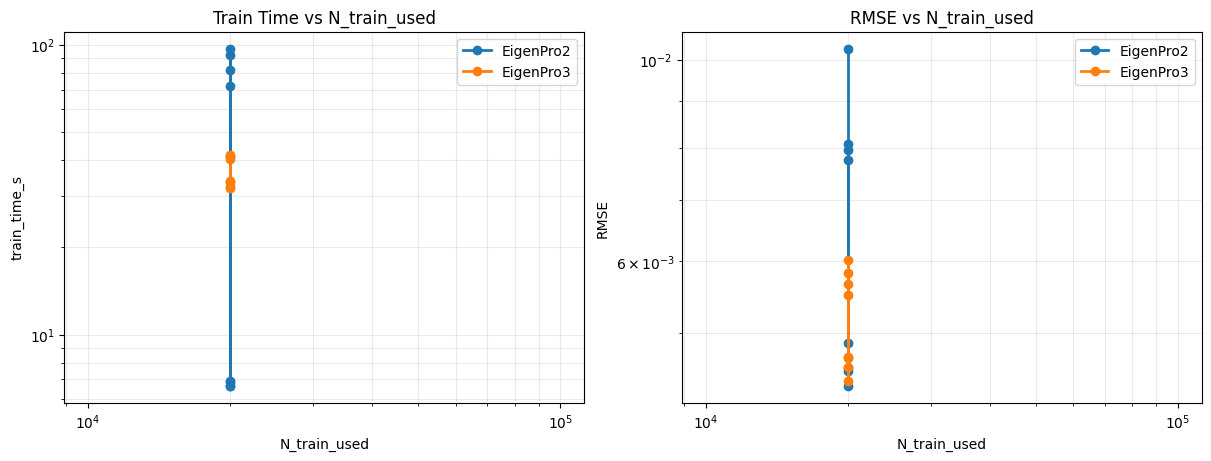

In [ ]:
# ---- Simple comparison plots ----
if summary_df.empty:
    print("summary_df is empty; skip plotting.")
else:
    plot_df = summary_df.copy()
    plot_df = plot_df.sort_values(["dataset", "method", "N_train_used"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

    for method_name, sub in plot_df.groupby("method", dropna=False):
        axes[0].plot(
            sub["N_train_used"],
            sub["train_time_s"],
            marker="o",
            linewidth=2,
            label=str(method_name),
        )
        axes[1].plot(
            sub["N_train_used"],
            sub["rmse"],
            marker="o",
            linewidth=2,
            label=str(method_name),
        )

    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("N_train_used")
    axes[0].set_ylabel("train_time_s")
    axes[0].set_title("Train Time vs N_train_used")
    axes[0].grid(True, which="both", alpha=0.25)
    axes[0].legend()

    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("N_train_used")
    axes[1].set_ylabel("RMSE")
    axes[1].set_title("RMSE vs N_train_used")
    axes[1].grid(True, which="both", alpha=0.25)
    axes[1].legend()

    plt.show()

# Accuracy-Based EigenPro / EFGP / Ours Protocol

This section implements the validation-RMSE target protocol. `EFGP-CG` / `gpu_v1_topq0` defines the target with `original` precompute; all other EFGP-family rows default to `c1` precompute. The test set is used only for final/best-validation evaluation.

In [ ]:
# ---- Accuracy-based protocol config ----
import importlib
from pathlib import Path
from IPython.display import display

import efgp_eigenpro_py.gpu.benchmark_dataset.accuracy_based_eigenpro_tables as acc_tables
acc_tables = importlib.reload(acc_tables)
AccuracyBenchmarkConfig = acc_tables.AccuracyBenchmarkConfig

# Smoke mode follows the implementation test plan. Set to False for the full benchmark.
ACCURACY_SMOKE_TEST = True

# Accuracy protocol dataset selection is independent from the earlier fixed-epoch section.
# ACCURACY_SMOKE_TEST=True ignores this and uses AccuracyBenchmarkConfig.smoke().
ACC_N_TRAIN_LIST = [
    100_000,
    #300_000,
    #1_000_000,
    #3_000_000,
    #10_000_000,
    #30_000_000,
    #100_000_000,
]
ACC_SYNTHETIC_DATASET_STEMS = [f"synthetic_true_func_2d_n{int(n)}" for n in ACC_N_TRAIN_LIST]
ACC_USGS_BASE_STEM = "USGS_LPC_IL_Winnebago_2018_ground_elevation_regression"
ACC_USGS_DATASET_STEMS = [f"{ACC_USGS_BASE_STEM}_ntrain{int(n)}" for n in ACC_N_TRAIN_LIST]
ACC_USE_UPPER_DATASET_SELECTION = False
ACC_DATASET_SELECTION_LIST = [
    *ACC_SYNTHETIC_DATASET_STEMS,
    # *ACC_USGS_DATASET_STEMS[:3],
]


def _accuracy_dataset_stems():
    if ACC_USE_UPPER_DATASET_SELECTION:
        return list(DATASET_SELECTION)
    return [Path(str(x)).stem for x in ACC_DATASET_SELECTION_LIST]

# ---- GPU benchmark aligned knobs ----
# These mirror gpu_benchmark_datasets.ipynb so this notebook controls the same EFGP-family settings.
ACC_EPS_LIST = [1e-5]
ACC_PRECOMPUTE_METHODS = {"EFGP-CG": "original", "default": "c1"}
ACC_PRECOMPUTE_C1_MIN_N_TOTAL = None  # None: all non-EFGP-CG EFGP-family rows request C1; set an int to force small-N fallback.
ACC_ADD_FASTEST_OURS_ROW = True  # Add derived method="ours" rows selecting the fastest EFGP-family q match.

ACC_REG_LAMBDA = 0.1
ACC_SOLVE_TOL = 1e-6
ACC_GPU_MAXITER = 6000
ACC_GPU_NUFFT = "auto"
ACC_L2_SCALED = True

ACC_V3_TOPQ_LIST = [45, 90, 135, 180, 360]
ACC_NYSTROM_TOPQ_LIST = [45, 90, 135, 180, 360]
ACC_EXTRA_TOPQ_LIST = list(ACC_V3_TOPQ_LIST)

ACC_EIG_METHOD_TOGGLES = {
    # baselines
    "baseline_v1_topq0": True,
    "baseline_v3_topq": True,
    # EigenPro Nystrom main (gpu_v3_topq_eigenpro_nystrom)
    "nystrom_compact_coordinate": True,
    # extra eigenspace algorithms
    "extra_rand_range_onepass": True,
}

ACC_EIGENPRO_NYSTROM_PRECOND_KIND = "coordinate_nystrom"
ACC_EIGENPRO_NYSTROM_REFINE_MODE = "auto"
ACC_EIGENPRO_NYSTROM_SURROGATE_SIZE = 1600
ACC_EIGENPRO_NYSTROM_LOWFREQ_RATIO = 0.5
ACC_EIGENPRO_NYSTROM_OVERSAMPLE = 10
ACC_EIGENPRO_NYSTROM_RITZ_REFINE = True
ACC_EIGENPRO_NYSTROM_SEED = 0
ACC_EIGENPRO_NYSTROM_BLOCK_ROWS = 8192
ACC_EIGENPRO_NYSTROM_RITZ_BLOCK_COLS = 16
ACC_EIGENPRO_NYSTROM_LIFT = True
ACC_EIGENPRO_NYSTROM_REFINE_ITERS = 1
ACC_EIGENPRO_COORD_NYSTROM_GAMMA = 1.0

ACC_EXTRA_RAND_RANGE_OVERSAMPLE = 16
ACC_EXTRA_RAND_RANGE_POWER_ITERS = 0
ACC_EXTRA_RAND_RANGE_OMEGA_KIND = "gaussian"
ACC_EXTRA_RAND_RANGE_BLOCK_COLS = 16

# EigenPro2 can be numerically aggressive with its package-estimated step size on these kernels.
# Keep the scale explicit so smoke/full runs can tune it without touching the runner.
ACC_EP2_LR_SCALE = 0.01
ACC_EP2_STOP_ON_DIVERGENCE = True
ACC_EP2_DIVERGENCE_ABS_RMSE = 5.0
ACC_EP2_DIVERGENCE_TARGET_FACTOR = 50.0


def _apply_gpu_aligned_accuracy_config(acc_cfg):
    acc_cfg.eps_list = list(ACC_EPS_LIST)
    acc_cfg.precompute_methods = dict(ACC_PRECOMPUTE_METHODS)
    acc_cfg.precompute_c1_min_n_total = ACC_PRECOMPUTE_C1_MIN_N_TOTAL
    acc_cfg.add_fastest_ours_row = ACC_ADD_FASTEST_OURS_ROW
    acc_cfg.reg_lambda = ACC_REG_LAMBDA
    acc_cfg.solve_tol = ACC_SOLVE_TOL
    acc_cfg.gpu_maxiter = ACC_GPU_MAXITER
    acc_cfg.gpu_nufft = ACC_GPU_NUFFT
    acc_cfg.l2_scaled = ACC_L2_SCALED
    acc_cfg.v3_topq_list = list(ACC_V3_TOPQ_LIST)
    acc_cfg.nystrom_topq_list = list(ACC_NYSTROM_TOPQ_LIST)
    acc_cfg.extra_topq_list = list(ACC_EXTRA_TOPQ_LIST)
    acc_cfg.eig_method_toggles = dict(ACC_EIG_METHOD_TOGGLES)
    acc_cfg.eigenpro_nystrom_precond_kind = ACC_EIGENPRO_NYSTROM_PRECOND_KIND
    acc_cfg.eigenpro_nystrom_refine_mode = ACC_EIGENPRO_NYSTROM_REFINE_MODE
    acc_cfg.eigenpro_nystrom_surrogate_size = ACC_EIGENPRO_NYSTROM_SURROGATE_SIZE
    acc_cfg.eigenpro_nystrom_lowfreq_ratio = ACC_EIGENPRO_NYSTROM_LOWFREQ_RATIO
    acc_cfg.eigenpro_nystrom_oversample = ACC_EIGENPRO_NYSTROM_OVERSAMPLE
    acc_cfg.eigenpro_nystrom_ritz_refine = ACC_EIGENPRO_NYSTROM_RITZ_REFINE
    acc_cfg.eigenpro_nystrom_seed = ACC_EIGENPRO_NYSTROM_SEED
    acc_cfg.eigenpro_nystrom_block_rows = ACC_EIGENPRO_NYSTROM_BLOCK_ROWS
    acc_cfg.eigenpro_nystrom_ritz_block_cols = ACC_EIGENPRO_NYSTROM_RITZ_BLOCK_COLS
    acc_cfg.eigenpro_nystrom_lift = ACC_EIGENPRO_NYSTROM_LIFT
    acc_cfg.eigenpro_nystrom_refine_iters = ACC_EIGENPRO_NYSTROM_REFINE_ITERS
    acc_cfg.eigenpro_coord_nystrom_gamma = ACC_EIGENPRO_COORD_NYSTROM_GAMMA
    acc_cfg.extra_rand_range_oversample = ACC_EXTRA_RAND_RANGE_OVERSAMPLE
    acc_cfg.extra_rand_range_power_iters = ACC_EXTRA_RAND_RANGE_POWER_ITERS
    acc_cfg.extra_rand_range_omega_kind = ACC_EXTRA_RAND_RANGE_OMEGA_KIND
    acc_cfg.extra_rand_range_block_cols = ACC_EXTRA_RAND_RANGE_BLOCK_COLS
    acc_cfg.ep2_lr_scale = ACC_EP2_LR_SCALE
    acc_cfg.ep2_stop_on_divergence = ACC_EP2_STOP_ON_DIVERGENCE
    acc_cfg.ep2_divergence_abs_rmse = ACC_EP2_DIVERGENCE_ABS_RMSE
    acc_cfg.ep2_divergence_target_factor = ACC_EP2_DIVERGENCE_TARGET_FACTOR
    return acc_cfg


if ACCURACY_SMOKE_TEST:
    acc_cfg = _apply_gpu_aligned_accuracy_config(AccuracyBenchmarkConfig.smoke())
    # Keep smoke small while preserving the same method families.
    acc_cfg.v3_topq_list = [ACC_V3_TOPQ_LIST[0]]
    acc_cfg.nystrom_topq_list = [ACC_NYSTROM_TOPQ_LIST[0]]
    acc_cfg.extra_topq_list = [ACC_EXTRA_TOPQ_LIST[0]]
else:
    acc_cfg = _apply_gpu_aligned_accuracy_config(
        AccuracyBenchmarkConfig(
            dataset_stems=_accuracy_dataset_stems(),
            kernel_specs=list(KERNEL_SPECS),
        )
    )

print("ACCURACY_SMOKE_TEST:", ACCURACY_SMOKE_TEST)
print("run_tag:", acc_cfg.run_tag)
print("ACC_USE_UPPER_DATASET_SELECTION:", ACC_USE_UPPER_DATASET_SELECTION)
print("ACC_N_TRAIN_LIST:", ACC_N_TRAIN_LIST)
print("dataset_stems:", acc_cfg.dataset_stems)
print("kernel_specs:", acc_cfg.kernel_specs)
print("eps_list:", acc_cfg.eps_list)
print("reg_lambda / solve_tol / gpu_maxiter / l2_scaled:", acc_cfg.reg_lambda, acc_cfg.solve_tol, acc_cfg.gpu_maxiter, acc_cfg.l2_scaled)
print("precompute policy:", acc_cfg.precompute_methods, "c1_min_n_total=", acc_cfg.precompute_c1_min_n_total)
print("add_fastest_ours_row:", acc_cfg.add_fastest_ours_row)
print("eig_method_toggles:", acc_cfg.eig_method_toggles)
print("fixed EFGP-family specs:", acc_tables.build_fixed_efgp_method_specs(acc_cfg))
print("N_VAL_EVAL:", acc_cfg.n_val_eval, "N_TEST_EVAL:", acc_cfg.n_test_eval)
print("MAX_EPOCHS:", acc_cfg.max_epochs, "target_window:", acc_cfg.target_window, "target_delta:", acc_cfg.target_delta)
print("EigenPro2 lr_scale / stop_on_divergence:", acc_cfg.ep2_lr_scale, acc_cfg.ep2_stop_on_divergence)
print("EigenPro3 p sweep:", acc_cfg.eigenpro3_p_centers_list)


In [ ]:
# ---- Run accuracy-based benchmark tables ----
RUN_ACCURACY_BENCHMARK = True

if RUN_ACCURACY_BENCHMARK:
    acc_result = acc_tables.run_accuracy_benchmark(acc_cfg)
    print("accuracy benchmark output dir:", acc_result["out_dir"])
    print("config:", acc_result["config_path"])
    print("time-to-target:", acc_result["time_to_target_path"])
    print("same-time-budget:", acc_result["same_budget_path"])
    print("raw eval history:", acc_result["history_path"])

    display(acc_result["time_to_target_summary"])
    display(acc_result["same_time_budget_summary"])
    display(acc_result["raw_eval_history"].tail(20))
else:
    print("Set RUN_ACCURACY_BENCHMARK=True to generate the accuracy-based CSV tables.")


In [ ]:
'''
# ---- Optional Colab export / download / disconnect ----
# Default: commented out. Run manually after a benchmark finishes if you want a zip backup.
import json
import shutil
import time
from datetime import timedelta
from pathlib import Path

try:
    from google.colab import files, runtime
    _HAS_COLAB_EXPORT = True
except Exception:
    files = None
    runtime = None
    _HAS_COLAB_EXPORT = False

end_time = time.time()
try:
    elapsed_total = end_time - start_time
    time_str = str(timedelta(seconds=int(elapsed_total)))
except NameError:
    time_str = "unknown (start_time was not set)"

if "acc_result" in globals() and isinstance(acc_result, dict) and "out_dir" in acc_result:
    out_dir_path = Path(acc_result["out_dir"]).resolve()
else:
    out_dir_path = Path(OUT_DIR).resolve()

notebook_src_path = (Path(BENCHMARK_DIR) / "benchmark_eigenpro_baselines.ipynb").resolve()
if "DRIVE_OUTPUT_DIR" in globals():
    drive_output_dir = Path(DRIVE_OUTPUT_DIR)
else:
    drive_output_dir = Path(DRIVE_MYDRIVE_DIR) / "EFGP_Eigenpro" / "benchmark_exports"
drive_output_dir.mkdir(parents=True, exist_ok=True)

zip_name = f"{out_dir_path.name}_bundle.zip"
export_root = out_dir_path.parent / f"{out_dir_path.name}_export_bundle"
zip_base = out_dir_path.parent / f"{out_dir_path.name}_bundle"
zip_path = Path(f"{zip_base}.zip")
target_drive_path = drive_output_dir / zip_name

required_checks = {
    "out_dir_exists": out_dir_path.exists(),
    "notebook_exists": notebook_src_path.exists(),
}
print("artifact checks:", json.dumps({k: bool(v) for k, v in required_checks.items()}, indent=2))
if not bool(required_checks["out_dir_exists"]):
    raise FileNotFoundError(f"OUT_DIR not found: {out_dir_path}")

if export_root.exists():
    shutil.rmtree(export_root)
export_root.mkdir(parents=True, exist_ok=True)

export_results_dir = export_root / out_dir_path.name
shutil.copytree(out_dir_path, export_results_dir)

notebook_dst_dir = export_root / "notebook"
notebook_dst_dir.mkdir(parents=True, exist_ok=True)
if notebook_src_path.exists():
    shutil.copy2(notebook_src_path, notebook_dst_dir / notebook_src_path.name)

export_manifest = {
    "run_tag": out_dir_path.name,
    "elapsed": time_str,
    "export_root": str(export_root),
    "out_dir": str(out_dir_path),
    "notebook_src": str(notebook_src_path),
    "drive_output_dir": str(drive_output_dir),
    "includes": [
        str(export_results_dir),
        str(notebook_dst_dir / notebook_src_path.name) if notebook_src_path.exists() else "notebook_missing",
    ],
}
(export_root / "export_manifest.json").write_text(json.dumps(export_manifest, indent=2), encoding="utf-8")

if zip_path.exists():
    zip_path.unlink()
print(f"Packing export bundle: {export_root}")
shutil.make_archive(str(zip_base), "zip", root_dir=str(export_root.parent), base_dir=export_root.name)
print("zip saved:", zip_path)

print(f"Copying zip to Google Drive: {target_drive_path}")
shutil.copy2(zip_path, target_drive_path)

local_ok = zip_path.exists() and zip_path.stat().st_size > 0
drive_ok = target_drive_path.exists() and target_drive_path.stat().st_size > 0
print("local zip ok:", local_ok)
print("drive zip ok:", drive_ok)

if local_ok:
    if _HAS_COLAB_EXPORT and files is not None:
        print("Starting browser backup download...")
        files.download(str(zip_path))
    else:
        print("Not in Colab; browser download skipped.")

print("-" * 30)
print("Experiment status:", "completed and backed up" if drive_ok else "local zip ok, Drive sync failed")
print(f"Elapsed: {time_str}")
print("OUT_DIR:", out_dir_path)
print("Local zip:", zip_path)
print("Drive zip:", target_drive_path)
print("-" * 30)

if drive_ok and _HAS_COLAB_EXPORT and runtime is not None:
    print("Disconnecting Colab runtime in 20 seconds to save GPU quota...")
    time.sleep(20)
    runtime.unassign()
elif not drive_ok:
    print("Drive sync check failed; automatic disconnect cancelled.")
'''
